# Algoritmo Apriori

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from plotly.subplots import make_subplots
import seaborn as sns

from mlxtend.frequent_patterns import apriori, association_rules

## Carregar os Dados
### Dataset
- POS Txn = id da transação.
- Dept = <id do dep>:<nome do departamento>.
- ID = id do de departamento em outro produto.
- Sales = Quantas unidades vendidas do departamento do produto

In [60]:
df_transacoes = pd.read_csv("./dataset/market.csv", sep=',')
df_transacoes.info()

<class 'pandas.DataFrame'>
RangeIndex: 4539 entries, 0 to 4538
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   POS Txn  4539 non-null   uint64
 1   Dept     4539 non-null   str   
 2   ID       4539 non-null   int64 
 3   Sales U  4539 non-null   int64 
dtypes: int64(2), str(1), uint64(1)
memory usage: 142.0 KB


In [61]:
df_transacoes.head()

,POS Txn,Dept,ID,Sales U
0,16120100160021008773,0261:HOSIERY,250,2
1,16120100160021008773,0634:VITAMINS & HLTH AIDS,102,1
2,16120100160021008773,0879:PET SUPPLIES,158,2
3,16120100160021008773,0973:CANDY,175,2
4,16120100160021008773,0982:SPIRITS,176,1


In [62]:
df_transacoes.describe()

,POS Txn,ID,Sales U
count,4.539000e+03,4539.000000,4539.000000
mean,1.612010e+19,137.546816,1.764265
std,3.282793e+07,67.255705,1.842388
min,1.612010e+19,1.000000,-9.000000
25%,1.612010e+19,93.000000,1.000000
50%,1.612010e+19,152.000000,1.000000
75%,1.612010e+19,176.000000,2.000000
max,1.612010e+19,311.000000,24.000000


## Análise Exploratória

### Renomear colunas

In [63]:
df_eda = df_transacoes.rename(columns={
  'POS Txn': 'ID_Transacao',
  'Dept': 'Departamento',
  'ID': 'ID_Departamento',
  "Sales U": "Qtd_Vendida",
})

df_eda.columns.to_list()

['ID_Transacao', 'Departamento', 'ID_Departamento', 'Qtd_Vendida']

### Quantidade de Itens

In [64]:
# Quantidade de departamentos
len(df_eda['Departamento'].unique())

160

In [65]:
# Ver se tem o mesmo número de ids e quantidade e departamento
len(df_eda['ID_Departamento'].unique())

160

In [66]:
# Quantidade de transações
len(df_eda['ID_Transacao'].unique())

2064

In [67]:
# Vê se há repetição de departamento dentro de transação
len(df_eda.groupby(['ID_Transacao', 'Departamento'])) != len(df_transacoes)

False

### Ver se há quantidade vendida negativa ou nula

In [68]:
len(df_eda[df_eda['Qtd_Vendida'] <= 0])

149

### Remover quantidades vendidas negativas ou nulas

In [69]:
df_eda = df_eda[df_eda['Qtd_Vendida'] > 0]

### Quais departamentos têm o maior volume de transações e maior quantidade de unidades vendidas?

In [70]:
contagem_por_departamento = df_eda.value_counts('Departamento').sort_values(ascending=False) # type: ignore
fig_volume_transacoes = px.bar(contagem_por_departamento, color=contagem_por_departamento.index, orientation='h')
fig_volume_transacoes.update_layout(showlegend=False)
fig_volume_transacoes.update_yaxes(autorange='reversed')
fig_volume_transacoes.show()

### Mostrar somente o top 10

In [71]:
contagem_por_departamento_top10 = df_eda.value_counts('Departamento').head(10).sort_values(ascending=False) # type: ignore

fig_volume_transacoes_top10 = px.bar(contagem_por_departamento_top10, color=contagem_por_departamento_top10.index, orientation='h')
fig_volume_transacoes_top10.update_layout(showlegend=False)
fig_volume_transacoes_top10.update_yaxes(autorange='reversed')
fig_volume_transacoes_top10.show()

### Quais departamentos venderam mais - top 10

In [72]:
soma_por_departamento = df_eda.groupby("Departamento")['Qtd_Vendida'].sum().sort_values(ascending=False).head(10)
fig_unidades_vendidas_top10 = px.bar(soma_por_departamento, color=soma_por_departamento.index, orientation='h')
fig_unidades_vendidas_top10.update_layout(showlegend=False)
fig_unidades_vendidas_top10.update_yaxes(autorange='reversed')
fig_unidades_vendidas_top10.show()

### Unificar gŕaficos de Top 10

In [73]:
fig_pergunta_1 = make_subplots(
  rows=1,
  cols=2,
  subplot_titles=('Volume de Transações', 'Unidades Vendidas')
)

for trace in fig_volume_transacoes_top10['data']:
    fig_pergunta_1.add_trace(trace, row=1, col=1)

for trace in fig_unidades_vendidas_top10['data']:
    fig_pergunta_1.add_trace(trace, row=1, col=2)

fig_pergunta_1.update_layout(height=600, width=1400, title_text='Top 10 Departamentos', showlegend=False)

fig_pergunta_1.show()

### Departamentos com maior variação de unidade vendida por transação - Top 20

In [74]:
std_por_departamento_top20 = df_eda.groupby("Departamento")['Qtd_Vendida'].std().sort_values(ascending=False).head(20)
fig_std_top20 = px.bar(std_por_departamento_top20, color=std_por_departamento_top20.index, orientation='h')
fig_std_top20.update_layout(showlegend=False)
fig_std_top20.update_yaxes(autorange='reversed')
fig_std_top20.show()

### Distribuição Unidades Vendidas por Departamento nas diferentes transações

In [75]:
px.box(
  df_eda,
  x='Departamento',
  y='Qtd_Vendida'
)

### Média de Unidades Vendidas por Departamento

In [76]:
mean_por_departamento_top20 = df_eda.groupby("Departamento")['Qtd_Vendida'].mean().sort_values(ascending=False).head(20)
fig_mean_top20 = px.bar(mean_por_departamento_top20, color=mean_por_departamento_top20.index, orientation='h')
fig_mean_top20.update_layout(showlegend=False)
fig_mean_top20.update_yaxes(autorange='reversed')
fig_mean_top20.show()

In [77]:
fig_pergunta_4 = make_subplots(
  rows=1,
  cols=2,
  subplot_titles=('Desvio Padrão', 'Média')
)

for trace in fig_std_top20['data']:
    fig_pergunta_4.add_trace(trace, row=1, col=1)

for trace in fig_mean_top20['data']:
    fig_pergunta_4.add_trace(trace, row=1, col=2)

fig_pergunta_4.update_layout(height=800, width=1400, title_text='Top 20 Departamentos - Unidades Vendidas', showlegend=False)

fig_pergunta_4.show()

## Preparação da Base com Pivot Table
### Ex:
|ID_Trans|Prod1|Prod2|Prod3|Prod4|
|:-:|:-:|:-:|:-:|:-:|
|00000001|X    |X    |     |     |
|00000002|X    |X    |X    |X    |
|00000003|     |X    |X    |X    |

- ID_Transação como Registro
- Departamento como Coluna
- Soma de Quantidade Vendida como Valor

In [78]:
# Renomeia colunas do dataframe original
df_transacoes.rename(columns={
  'POS Txn': 'ID_Transacao',
  'Dept': 'Departamento',
  'ID': 'ID_Departamento',
  "Sales U": "Qtd_Vendida",
}, inplace=True)

# Tira quantidade negativa de vendas
df_transacoes = df_transacoes[df_transacoes['Qtd_Vendida'] > 0]

# Pivot Table
df_transacoes_pivot = df_transacoes.pivot_table(
  index='ID_Transacao',
  columns='Departamento',
  values='Qtd_Vendida',
  aggfunc='sum',
)

df_transacoes_pivot.shape

(1943, 156)

In [79]:
df_transacoes_pivot = df_transacoes_pivot.map(lambda x: True if x > 0 else False)
pd.set_option('display.max_columns', None)
df_transacoes_pivot.head()

Departamento,0002:BARBER RETAIL,0009:FLORAL SERV/SUPPLIES,0012:LOCAL GIFTS/FOODS,0014:REPAIRS,0016:FINANCIAL SERVICES,0018:OTHER DIRECT SERVICE,0033:VENDING RETAIL,0056:SOUVENIR,0066:VENDING/AMUSEMENT MA,0071:BEAUTY RETAIL,0072:BARBER SERVICES,0076:FLORAL RETAIL,0098:WAREHOUSED EXPENSES,0099:MISC CUSTOM SERVICES,0110:LDS OUTERWEAR/OUTDR,0130:JUNIORS SURF,0131:LADIES DRESSES,0161:MISSY KAREN SCOTT,0163:JUNIOR TOPS,0165:LIFE IS GOOD,0167:MISSY TOPS,0171:MISSY BOTTOMS,0173:JUNIOR BOTTOMS,0175:WOMENS SEPARATES,0177:PETITE SEPARATES,0178:DENIM COLLECTIONS,0179:MODERATE DENIM,0181:LADIES MODERN COLLEC,0182:CLASSIC COLLECTIONS,0186:JUNIOR DRESSES,0188:STYLE & CO,0193:LADIES ACTIVEWEAR,0210:FOUNDATIONS,0220:SHAPEWEAR,0230:DAYWEAR,0240:SLEEPWEAR/LOUNGEWEAR,0261:HOSIERY,0271:HANDBAGS,0280:FASHION ACCESSORIES,0291:WOMENS FTWR:DRS/CAS,0295:WOMENS ATHLTIC SHOES,0310:MENS OUTERWEAR,0320:MNS TAILORED CLOTHNG,0340:MENS CASUAL SLACKS,0343:MENS DENIM JEANS,0346:LIFE STYLE DENIM,0353:MENS OUTDOOR,0354:MENS MODERN COLLECT,0355:MENS SPORT SHIRTS,0358:MENS DRESS SHIRTS,0359:MENS ACCESSORIES,0360:MENS FURNISHINGS,0368:TRAD COLLECTIONS,0369:YOUNG MENS,0380:MENS ACTIVEWEAR,0391:MENS SHOES,0395:MENS ATHLETIC SHOES,0411:PEGABLES,0415:NEWBORN APPAREL,0416:INFANT APPAREL,0421:TODDLER GIRL APPAREL,0426:TODDLER BOY APPAREL,0430:GIRLS 4-6X CLOTHING,0439:JUVENILLE FURNITURE,0440:GIRLS 7-16 CLOTHING,0449:GIRLS ACCESSORIES,0460:BOYS 4-7 CLOTHING,0469:BOYS ACCESSORIES,0470:BOYS 8-20 CLOTHING,0486:CHILDRENS FOOTWEAR,0510:NAVY PRIDE HARDLINES,0511:NAVY PRIDE SOFTLINES,0530:SCHOOL/OFFIC SUPP,0531:STATIONERY SUNDRIES,0532:AMERICAN GREETINGS,0533:PAPYRUS,0540:PERIODICALS/COMICS,0541:BOOKS AND MAPS,0551:CAMERAS & EQUIP,0554:TELECOMMUNICATIONS,0581:BRIDGE JEWELRY,0582:GOLD,0583:DIAMONDS/BRIDAL,0584:GEMSTONES,0585:WATCHES,0586:COSTUME JEWELRY,0587:JEWELRY CONSIGNMENT,0589:SUNGLASSES,0590:MASS COSMETICS,0591:MASS FRAGRANCES,0592:WMNS PRESTIGE FRAG,0593:PRESTIGE COSMETICS,0595:HOME/BATH,0596:MENS PRESTIGE FRAG,0597:HEALTH AIDS,0598:BABY CARE,0601:VALUE ZONE,0603:BEAUTY CARE,0604:PERSONAL CARE,0632:DIGITAL FITNESS,0634:VITAMINS & HLTH AIDS,0636:FITNESS/EXERCISE,0637:FISHING,0638:GEN SPORTING GOODS,0639:TEAM SPORTING GOODS,0640:TOYS,0644:SPORTS NUTRITION,0645:BIKES,0646:SEASONAL,0661:LUGGAGE,0680:AUTOMOTIVE,0722:OUTDOOR LIVING,0795:HOME DECOR,0797:SEASONAL GIFTS,0811:TELEVISION,0815:AUDIO ELECTRONICS,0816:VIDEO ELECTRONICS,0817:WEARABLES,0819:PRE-RECORDED A/V,0822:THIRD PARTY GIFTCARD,0823:SMART HOME,0826:SMALL ELECTRICS,0833:TABLETOP,0834:COOKWARE,0836:HOUSEHOLD CLEANING,0837:GENERAL HOUSEWARES,0838:FLOOR CARE,0839:HOME ORG/SOLUTIONS,0845:AS SEEN ON TV,0846:BATTERIES,0850:PC HDWR & OFFICE EQP,0851:PC HARDWARE,0852:COMPUTER SOFTWARE,0853:DIMAGE/PHONE/GPS/ACC,0854:VIDEO GAMES,0856:GLUES/TAPES/ACC,0857:PC PERIPH/OFFICE ACC,0859:iPAD,0860:NETWORKING,0861:GENERAL HARDWARE,0863:POWER EQUIPMENT,0879:PET SUPPLIES,0884:LAWN & GARDEN,0930:TABLE TOP & KITCHEN,0931:BATH,0940:HOME TEXTILES,0941:BEDDING,0961:GENERAL GROCERIES,0962:BEVERAGES,0965:PERISHABLES,0973:CANDY,0982:SPIRITS,0983:WINE,0984:BEER,0991:TOBACCO,0999:UNSCANNED ITEMS
ID_Transacao,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
16120100160021008773,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,Fal

### Remover o título do departamento e tirar ID_Transacao como parte do índice

In [80]:
df_transacoes_pivot = df_transacoes_pivot.rename_axis(None, axis=1)

In [81]:
df_transacoes_pivot.reset_index(inplace=True)

In [82]:
df_transacoes_pivot.drop(columns=['ID_Transacao'], inplace=True)

In [83]:
df_transacoes_pivot.head()

,0002:BARBER RETAIL,0009:FLORAL SERV/SUPPLIES,0012:LOCAL GIFTS/FOODS,0014:REPAIRS,0016:FINANCIAL SERVICES,0018:OTHER DIRECT SERVICE,0033:VENDING RETAIL,0056:SOUVENIR,0066:VENDING/AMUSEMENT MA,0071:BEAUTY RETAIL,0072:BARBER SERVICES,0076:FLORAL RETAIL,0098:WAREHOUSED EXPENSES,0099:MISC CUSTOM SERVICES,0110:LDS OUTERWEAR/OUTDR,0130:JUNIORS SURF,0131:LADIES DRESSES,0161:MISSY KAREN SCOTT,0163:JUNIOR TOPS,0165:LIFE IS GOOD,0167:MISSY TOPS,0171:MISSY BOTTOMS,0173:JUNIOR BOTTOMS,0175:WOMENS SEPARATES,0177:PETITE SEPARATES,0178:DENIM COLLECTIONS,0179:MODERATE DENIM,0181:LADIES MODERN COLLEC,0182:CLASSIC COLLECTIONS,0186:JUNIOR DRESSES,0188:STYLE & CO,0193:LADIES ACTIVEWEAR,0210:FOUNDATIONS,0220:SHAPEWEAR,0230:DAYWEAR,0240:SLEEPWEAR/LOUNGEWEAR,0261:HOSIERY,0271:HANDBAGS,0280:FASHION ACCESSORIES,0291:WOMENS FTWR:DRS/CAS,0295:WOMENS ATHLTIC SHOES,0310:MENS OUTERWEAR,0320:MNS TAILORED CLOTHNG,0340:MENS CASUAL SLACKS,0343:MENS DENIM JEANS,0346:LIFE STYLE DENIM,0353:MENS OUTDOOR,0354:MENS MODERN COLLECT,0355:MENS SPORT SHIRTS,0358:MENS DRESS SHIRTS,0359:MENS ACCESSORIES,0360:MENS FURNISHINGS,0368:TRAD COLLECTIONS,0369:YOUNG MENS,0380:MENS ACTIVEWEAR,0391:MENS SHOES,0395:MENS ATHLETIC SHOES,0411:PEGABLES,0415:NEWBORN APPAREL,0416:INFANT APPAREL,0421:TODDLER GIRL APPAREL,0426:TODDLER BOY APPAREL,0430:GIRLS 4-6X CLOTHING,0439:JUVENILLE FURNITURE,0440:GIRLS 7-16 CLOTHING,0449:GIRLS ACCESSORIES,0460:BOYS 4-7 CLOTHING,0469:BOYS ACCESSORIES,0470:BOYS 8-20 CLOTHING,0486:CHILDRENS FOOTWEAR,0510:NAVY PRIDE HARDLINES,0511:NAVY PRIDE SOFTLINES,0530:SCHOOL/OFFIC SUPP,0531:STATIONERY SUNDRIES,0532:AMERICAN GREETINGS,0533:PAPYRUS,0540:PERIODICALS/COMICS,0541:BOOKS AND MAPS,0551:CAMERAS & EQUIP,0554:TELECOMMUNICATIONS,0581:BRIDGE JEWELRY,0582:GOLD,0583:DIAMONDS/BRIDAL,0584:GEMSTONES,0585:WATCHES,0586:COSTUME JEWELRY,0587:JEWELRY CONSIGNMENT,0589:SUNGLASSES,0590:MASS COSMETICS,0591:MASS FRAGRANCES,0592:WMNS PRESTIGE FRAG,0593:PRESTIGE COSMETICS,0595:HOME/BATH,0596:MENS PRESTIGE FRAG,0597:HEALTH AIDS,0598:BABY CARE,0601:VALUE ZONE,0603:BEAUTY CARE,0604:PERSONAL CARE,0632:DIGITAL FITNESS,0634:VITAMINS & HLTH AIDS,0636:FITNESS/EXERCISE,0637:FISHING,0638:GEN SPORTING GOODS,0639:TEAM SPORTING GOODS,0640:TOYS,0644:SPORTS NUTRITION,0645:BIKES,0646:SEASONAL,0661:LUGGAGE,0680:AUTOMOTIVE,0722:OUTDOOR LIVING,0795:HOME DECOR,0797:SEASONAL GIFTS,0811:TELEVISION,0815:AUDIO ELECTRONICS,0816:VIDEO ELECTRONICS,0817:WEARABLES,0819:PRE-RECORDED A/V,0822:THIRD PARTY GIFTCARD,0823:SMART HOME,0826:SMALL ELECTRICS,0833:TABLETOP,0834:COOKWARE,0836:HOUSEHOLD CLEANING,0837:GENERAL HOUSEWARES,0838:FLOOR CARE,0839:HOME ORG/SOLUTIONS,0845:AS SEEN ON TV,0846:BATTERIES,0850:PC HDWR & OFFICE EQP,0851:PC HARDWARE,0852:COMPUTER SOFTWARE,0853:DIMAGE/PHONE/GPS/ACC,0854:VIDEO GAMES,0856:GLUES/TAPES/ACC,0857:PC PERIPH/OFFICE ACC,0859:iPAD,0860:NETWORKING,0861:GENERAL HARDWARE,0863:POWER EQUIPMENT,0879:PET SUPPLIES,0884:LAWN & GARDEN,0930:TABLE TOP & KITCHEN,0931:BATH,0940:HOME TEXTILES,0941:BEDDING,0961:GENERAL GROCERIES,0962:BEVERAGES,0965:PERISHABLES,0973:CANDY,0982:SPIRITS,0983:WINE,0984:BEER,0991:TOBACCO,0999:UNSCANNED ITEMS
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,

### Matriz de Correlação no Pivot Table

<Axes: >

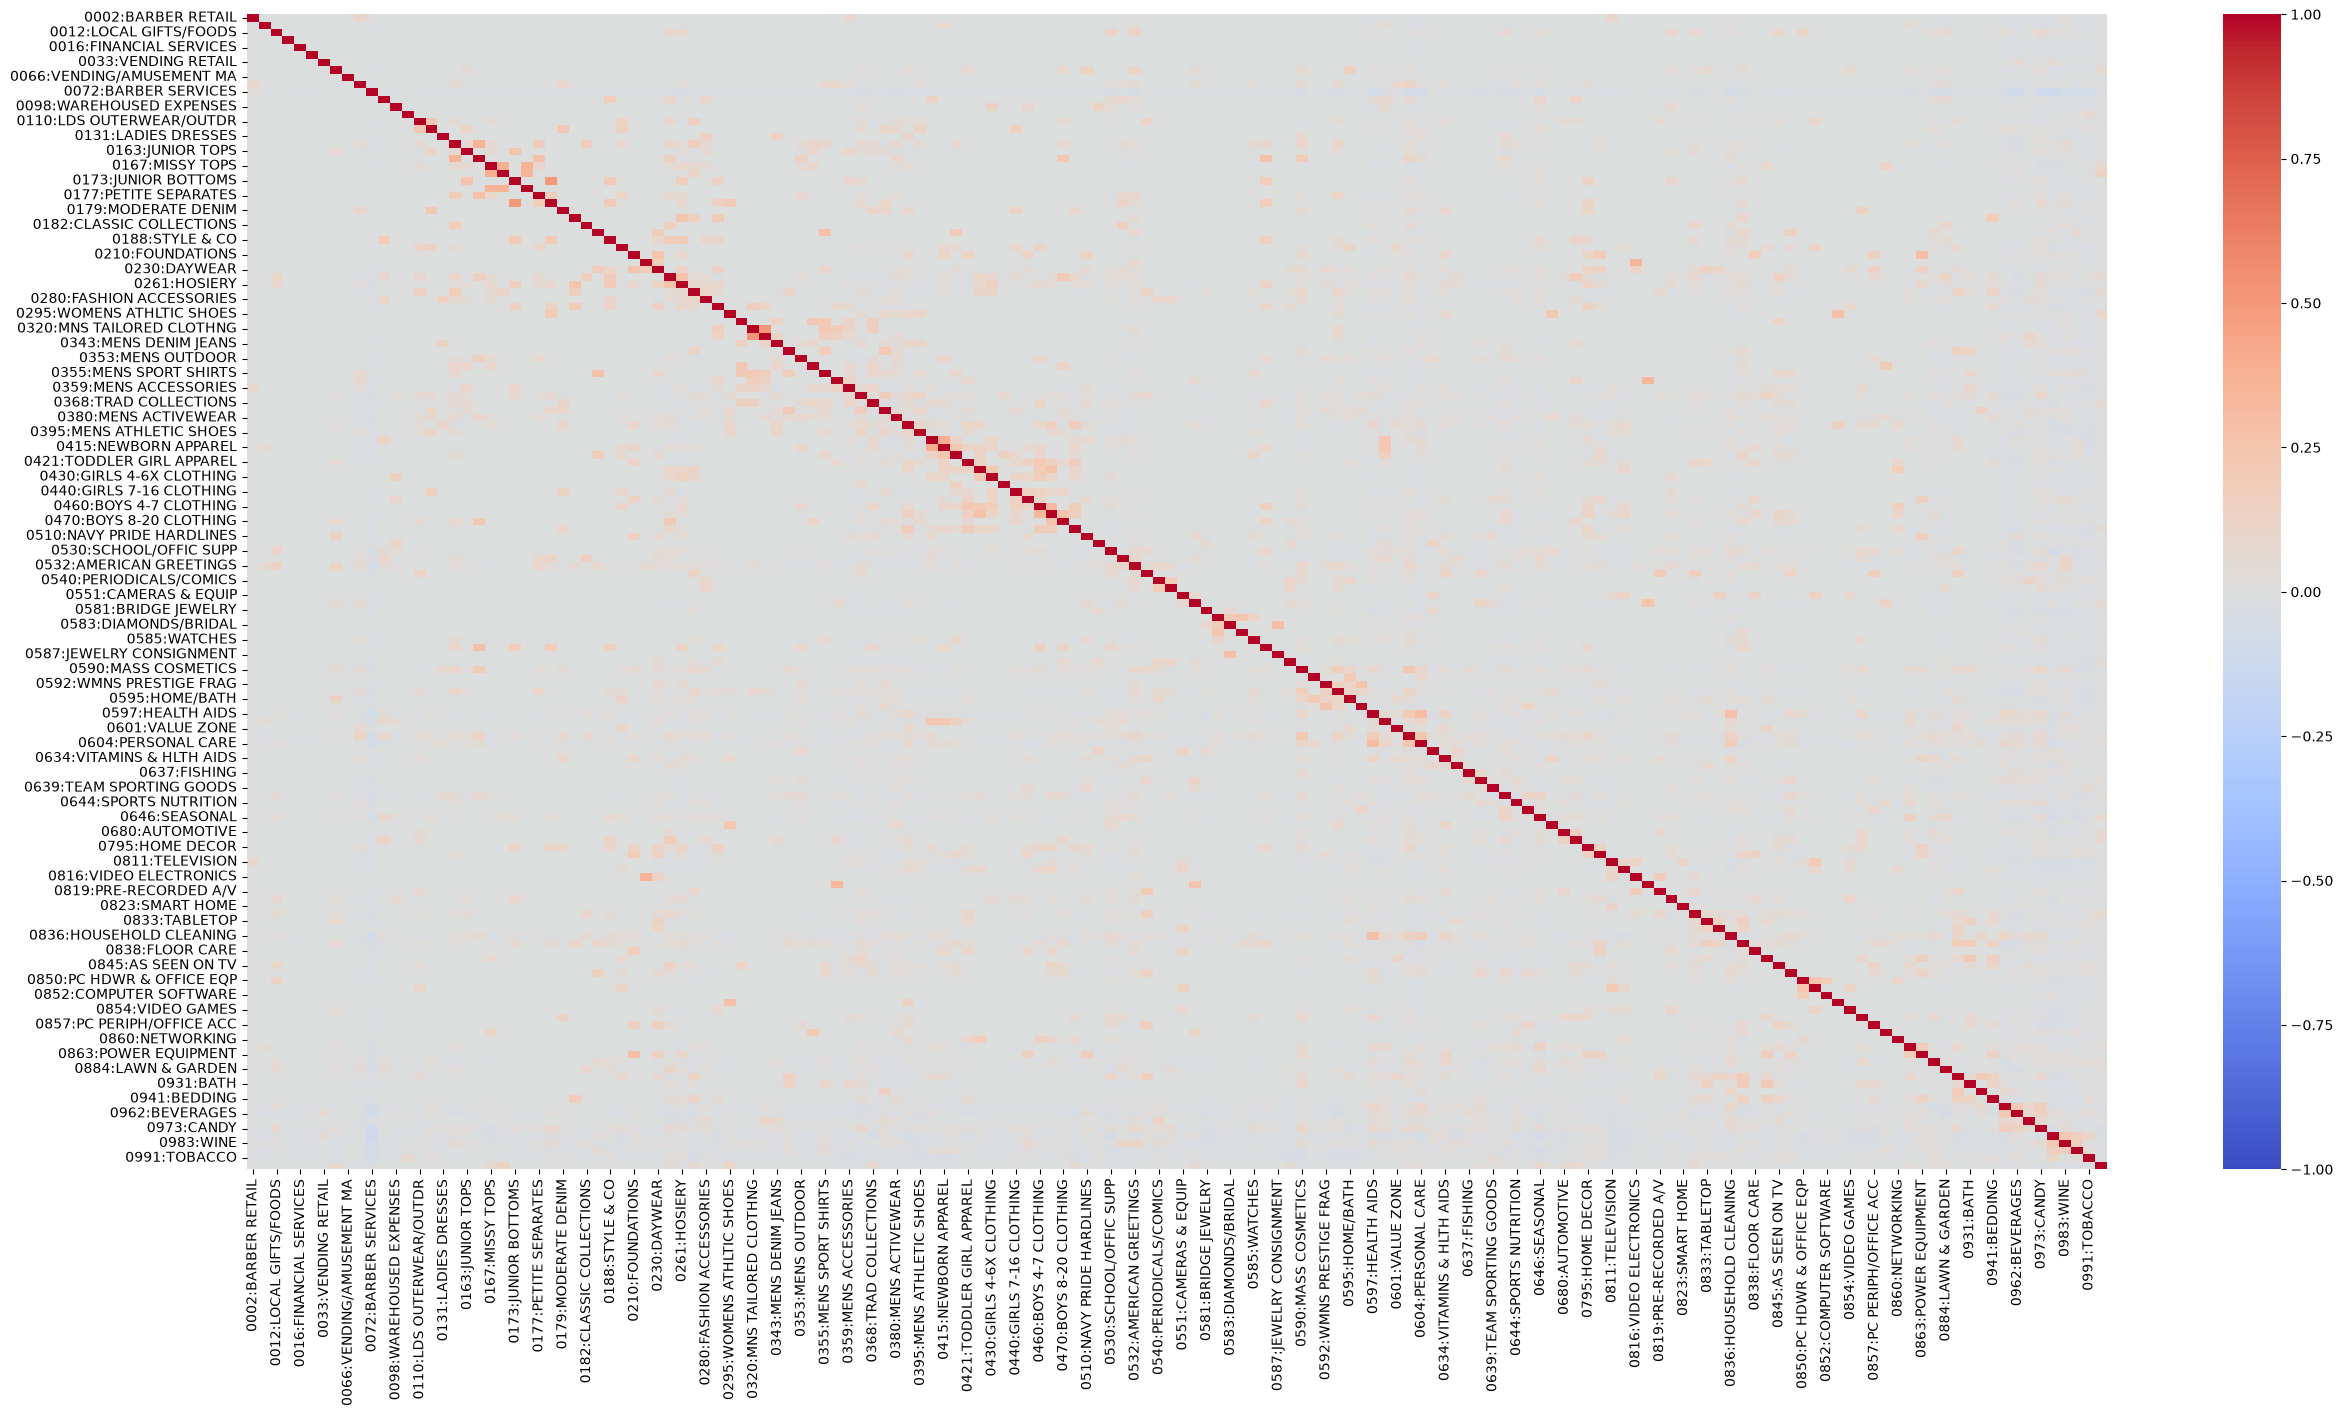

In [84]:
corr_pearson = df_transacoes_pivot.corr()
plt.figure(figsize=(30, 15))
sns.heatmap(
  corr_pearson,
  vmin=-1,
  vmax=1,
  cmap='coolwarm',
  annot=False
)

## Algoritmo Apriori

### Processando Itemsets
- Obs: o departamento mais frequente ocorre 314 vezes, o que é algo em torno de 16% das transações.
- Isso demanda que o suporte mínimo não seja elevado.
- Maioria dos itemsets são individuais, o que não interessa para formação de regras de associação.
- Por isso, pega-se itemsets com tamanho > 1.

In [85]:
itemsets_frequentes = apriori(df_transacoes_pivot, min_support=0.02, use_colnames=True, verbose=1)

Processing 6 combinations | Sampling itemset size 3 2


In [86]:
# Quantos itemsets frequentes
len(itemsets_frequentes)

36

In [87]:
# Criar uma coluna para armazenar o tamanho do itemset
itemsets_frequentes['tamanho'] = itemsets_frequentes['itemsets'].apply(lambda x: len(x))
itemsets_frequentes.sort_values(by=['tamanho', 'support'], ascending=False)

,support,itemsets,tamanho
33,0.039629,"frozenset({0983:WINE, 0982:SPIRITS})",2
31,0.034483,"frozenset({0962:BEVERAGES, 0973:CANDY})",2
25,0.032939,"frozenset({0604:PERSONAL CARE, 0597:HEALTH AIDS})",2
26,0.031395,"frozenset({0836:HOUSEHOLD CLEANING, 0597:HEALT...",2
35,0.026763,"frozenset({0982:SPIRITS, 0991:TOBACCO})",2
34,0.025733,"frozenset({0984:BEER, 0982:SPIRITS})",2
32,0.025219,"frozenset({0962:BEVERAGES, 0982:SPIRITS})",2
27,0.023160,"frozenset({0597:HEALTH AIDS, 0973:CANDY})",2
29,0.022131,"frozenset({0961:GENERAL GROCERIES, 0962:BEVERA...",2
24,0.021616,"frozenset({0603:BEAUTY CARE, 0597:HEALTH AIDS})",2


### Validar a informação de suporte
- Suporte = transações onde o item aparece / total de transações

In [88]:
transacoes_spirit = len(df_transacoes_pivot[df_transacoes_pivot['0982:SPIRITS'] == True])
total_transacoes = len(df_transacoes_pivot)
suporte_spirits = transacoes_spirit/total_transacoes
print(f"Suporte 0982:Spirits - {suporte_spirits}")

Suporte 0982:Spirits - 0.16160576428203807


### Criar Regras de Associação
- Usa-se confiança mínima de 40%
- Confiança(A=>B) = Número de Transações contendo A e B/Número Total de Transaçẽs contendo A

In [89]:
regras_associacao = association_rules(itemsets_frequentes, metric='confidence', min_threshold=0.4)

In [90]:
regras_associacao

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({0604:PERSONAL CARE}),frozenset({0597:HEALTH AIDS}),0.077200,0.102934,0.032939,0.426667,4.145067,1.0,0.024992,1.564651,0.822225,0.223776,0.360880,0.373333
1,frozenset({0961:GENERAL GROCERIES}),frozenset({0962:BEVERAGES}),0.050952,0.130211,0.022131,0.434343,3.335689,1.0,0.015496,1.537663,0.737805,0.139159,0.349662,0.302152
2,frozenset({0983:WINE}),frozenset({0982:SPIRITS}),0.098302,0.161606,0.039629,0.403141,2.494598,1.0,0.023743,1.404678,0.664450,0.179907,0.288093,0.324182
